In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [2]:
#load studentInfo 
df = pd.read_csv("studentInfo.csv")
print("studentInfo:\n", df.head(10))

studentInfo:
   code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   
5         AAA             2013J       38053      M                 Wales   
6         AAA             2013J       45462      M              Scotland   
7         AAA             2013J       45642      F  North Western Region   
8         AAA             2013J       52130      F   East Anglian Region   
9         AAA             2013J       53025      M          North Region   

             highest_education imd_band age_band  num_of_prev_attempts  \
0             HE Qualification  90-100%     55<=                     0   
1

In [ ]:
#exploring
#exploring the data in studentinfo file
for col in ["code_module","code_presentation", "id_student", "gender", "region", 
            "imd_band", "highest_education","age_band", 
            "disability","num_of_prev_attempts", "studied_credits", "final_result" ]:
    print(col, df[col].unique())

code_module ['AAA' 'BBB' 'CCC' 'DDD' 'EEE' 'FFF' 'GGG']
code_presentation ['2013J' '2014J' '2013B' '2014B']
id_student [  11391   28400   30268 ... 2648187 2679821 2684003]
gender ['M' 'F']
region ['East Anglian Region' 'Scotland' 'North Western Region'
 'South East Region' 'West Midlands Region' 'Wales' 'North Region'
 'South Region' 'Ireland' 'South West Region' 'East Midlands Region'
 'Yorkshire Region' 'London Region']
imd_band ['90-100%' '20-30%' '30-40%' '50-60%' '80-90%' '70-80%' '?' '60-70%'
 '40-50%' '10-20' '0-10%']
highest_education ['HE Qualification' 'A Level or Equivalent' 'Lower Than A Level'
 'Post Graduate Qualification' 'No Formal quals']
age_band ['55<=' '35-55' '0-35']
disability ['N' 'Y']
num_of_prev_attempts [0 1 2 4 3 5 6]
studied_credits [240  60 120  90 150 180 345 420 170  80  75 300 330 210 270 360 135  70
 225 585 325 130 195 105 655 165 100 390 220 160 250  30  40  45 400 235
 145 630 355  50 110 115  55  85 480 280 175  95 155 190 315 200 140 540
 310 370 

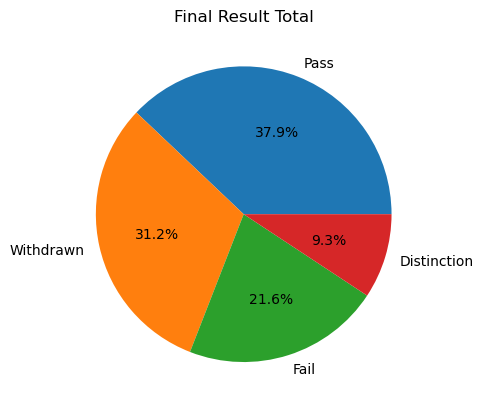

In [ ]:
#final Result Total 
result_counts = df["final_result"].value_counts()

plt.figure
#create a pie chart showing the percentage distribution of each category in result_counts
plt.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%')
plt.title("Final Result Total")
plt.show()

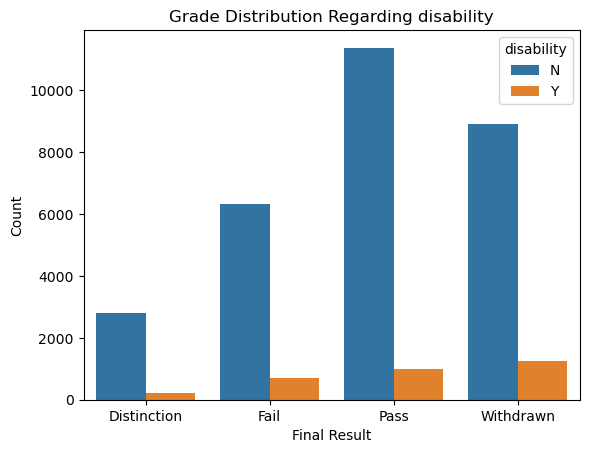

In [ ]:
#grade distribution Regarding disability
gender_grade = df.groupby(["disability", "final_result"]).size().reset_index(name="count")

plt.figure
#use Seaborn's barplot to quickly create a clean, grouped bar chart 
#that shows how final results vary by disability,
sns.barplot(data=gender_grade, x="final_result", y="count", hue="disability")
plt.title("Grade Distribution Regarding disability")
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.show()

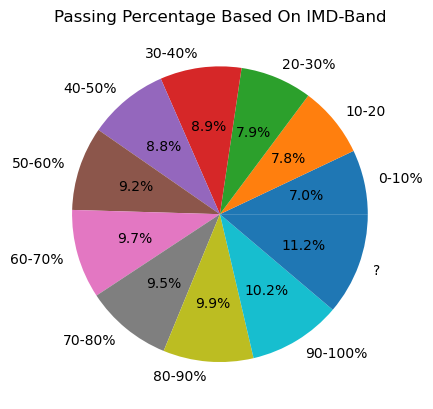

In [ ]:
#passing Percentage Based on IMD Band
imd_pass = df[df["final_result"] == "Pass"].groupby("imd_band").size()
imd_total = df.groupby("imd_band").size()
imd_percentage = (imd_pass/imd_total)*100

plt.figure
plt.pie(imd_percentage, labels=imd_percentage.index, autopct='%1.1f%%')
plt.title("Passing Percentage Based On IMD-Band")
plt.show()

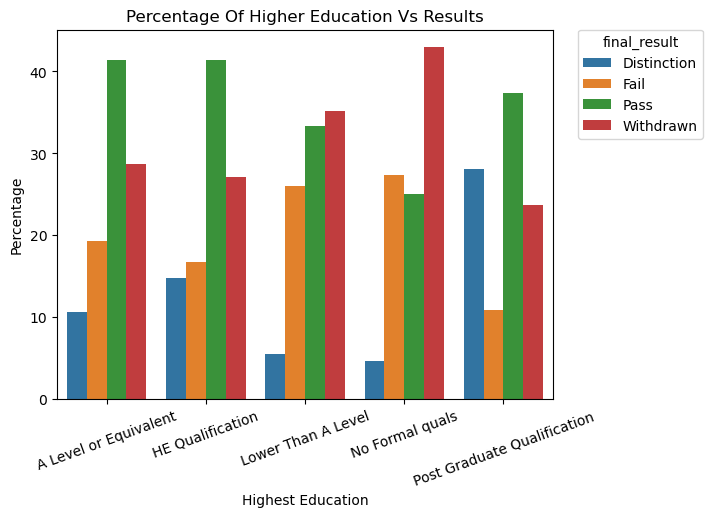

In [ ]:
#calculate how final results are distributed within each highest_education group.
#first, count the number of students for every (highest_education, final_result) combination.
edu_result = df.groupby(["highest_education", "final_result"]).size().reset_index(name="count")

#then compute the percentage each result contributes within its own education level.
#this loop finds the total count for each education group and converts each count into a percentage.
percentages = []
for e in edu_result["highest_education"].unique():
    subset = edu_result[edu_result["highest_education"] == e]
    total = subset["count"].sum()
    for c in subset["count"]:
        percentages.append((c / total)*100)

edu_result["percentage"] = percentages


plt.figure
#Use Seaborn's barplot to quickly create a clean, grouped bar chart 
sns.barplot(data=edu_result, x="highest_education", y="percentage", hue="final_result")
plt.legend(
    title="final_result",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)
plt.title("Percentage Of Higher Education Vs Results")
plt.xlabel("Highest Education")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.show()

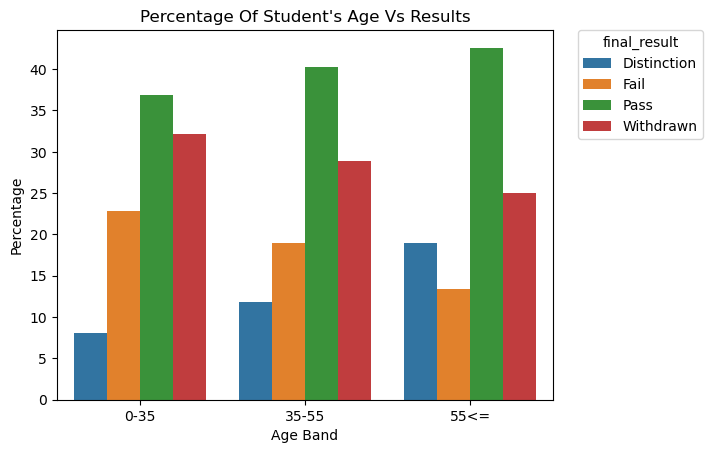

In [ ]:
#calculate how final results are distributed within each age_band group.
#first, count the number of students for every (age_band, final_result) combination.
age_result = df.groupby(["age_band", "final_result"]).size().reset_index(name="count")

#convert these counts into percentages within each age group.
#the loop finds the total number of students in each age_band and then
#calculates what percentage each final_result represents inside that group.
age_percentages = []
for age in age_result["age_band"].unique():
    subset = age_result[age_result["age_band"] == age]
    total = subset["count"].sum()
    for c in subset["count"]:
        age_percentages.append((c/total)*100)

age_result["percentage"] = age_percentages
plt.figure
#use Seaborn's barplot instead of matplot to quickly create a clean, grouped bar chart 
sns.barplot(data=age_result, x="age_band", y="percentage", hue="final_result")

plt.legend(
    title="final_result",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)
plt.title("Percentage Of Student's Age Vs Results")
plt.xlabel("Age Band")
plt.ylabel("Percentage")
plt.show()

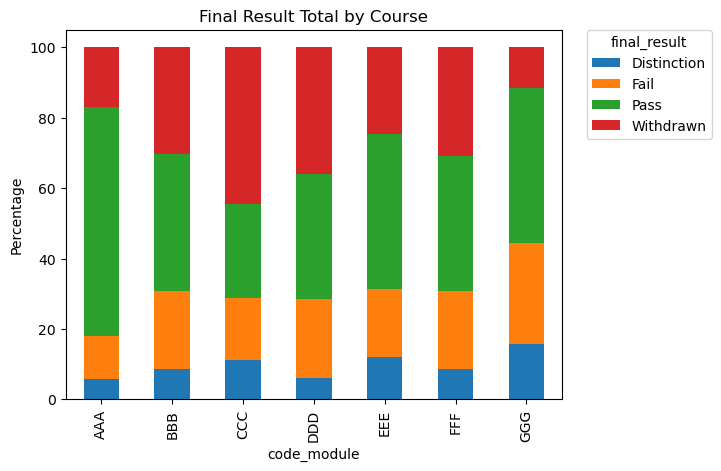

In [ ]:
#calculate how final results are distributed across each course module.
#first, count the number of students for every (code_module, final_result) combination.
course_result = df.groupby(["code_module", "final_result"]).size().reset_index(name="count")

#convert these counts into percentages within each module.
#for each module, find the total number of students and then work out
#what percentage each final_result represents inside that module.
percentages = []
for module in course_result["code_module"].unique():
    subset = course_result[course_result["code_module"] == module]
    total = subset["count"].sum()
    for c in subset["count"]:
        percentages.append((c/total)*100)

course_result["percentage"] = percentages

#reshape the data so each module becomes a row and each final_result a column,
#making it easier to plot a stacked bar chart of result percentages by module.
pivot_course = course_result.pivot(index="code_module", columns="final_result", values="percentage")
pivot_course.plot(kind="bar", stacked=True)

plt.legend(
    title="final_result",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)
plt.title("Final Result Total by Course")
plt.ylabel("Percentage")
plt.show()


Before: 32593
After: 31482


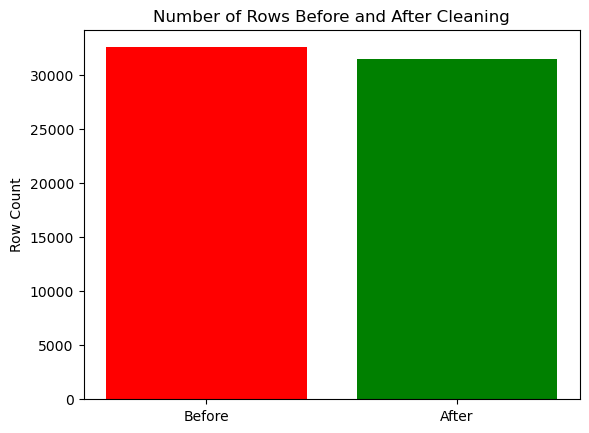

In [4]:
#cleaning

#replace '?' with NaN in all files
df = df.replace("?", np.nan)
#the sign 55<= looks nologic for me it should be >=55 or +55, so I fixed it 
df["age_band"] = df["age_band"].replace({"55<=": "55+"})
#the category 10-20 in imd_band without% so in the csv it appears as date( 20 oct) so i fixed it to be percentage
df["imd_band"] = df["imd_band"].replace({"10-20": "10-20%"})

#drop any row with missing value
df = df.dropna()
#drop unwanted studentInfo columns 
df = df.drop(columns=["id_student","code_presentation","code_module","num_of_prev_attempts","studied_credits"])

#check length before and after
before = len(pd.read_csv("studentInfo.csv"))
after = len(df) 
print("Before:", before) 
print("After:", after) 

plt.bar(["Before", "After"], [before, after], color=["red", "green"]) 
plt.title("Number of Rows Before and After Cleaning") 
plt.ylabel("Row Count") 
plt.show()


In [6]:
#save cleaned studentInfo
df.to_csv("studentInfo_cleaned.csv", index=False)


In [7]:

withdrawn_students = df[df["final_result"] == "Withdrawn"]

withdrawn_students.head()


,gender,region,highest_education,imd_band,age_band,disability,final_result
2,F,North Western Region,A Level or Equivalent,30-40%,35-55,Y,Withdrawn
15,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,N,Withdrawn
22,M,South Region,Lower Than A Level,70-80%,35-55,N,Withdrawn
29,M,South Region,HE Qualification,80-90%,35-55,N,Withdrawn
41,M,West Midlands Region,A Level or Equivalent,50-60%,0-35,N,Withdrawn


In [9]:
df[df["final_result"] == "Withdrawn"].value_counts()

gender  region                highest_education      imd_band  age_band  disability  final_result
M       North Western Region  Lower Than A Level     0-10%     0-35      N           Withdrawn       57
        London Region         A Level or Equivalent  20-30%    0-35      N           Withdrawn       38
F       London Region         Lower Than A Level     10-20%    0-35      N           Withdrawn       37
M       London Region         Lower Than A Level     10-20%    0-35      N           Withdrawn       36
F       North Western Region  Lower Than A Level     0-10%     0-35      N           Withdrawn       36
                                                                                                     ..
M       East Anglian Region   HE Qualification       30-40%    0-35      N           Withdrawn        1
        South West Region     A Level or Equivalent  50-60%    55+       N           Withdrawn        1
        East Anglian Region   HE Qualification       60-70%    0-35   

In [23]:
# Q1) Can demographic factors predict whether a student is likely to withdraw?
#create binary class label
df["Withdraw_Class"] = df["final_result"].map({
    "Withdrawn": 1,
    "Pass": 0,
    "Fail": 0,
    "Distinction": 0
})

#map categorical values to numbers
gender_map = {"M": 0, "F": 1}
df["gender_num"] = df["gender"].map(gender_map)

dis_map = {"N": 0, "Y": 1}
df["disability_num"] = df["disability"].map(dis_map)

age_map = {"0-35": 0, "35-55": 1, "55+": 2}
df["age_num"] = df["age_band"].map(age_map)
region_map = {
    "East Anglian Region": 0, "Scotland": 1, "North Western Region": 2, "South East Region": 3,
    "West Midlands Region": 4, "Wales": 5, "North Region": 6, "South Region": 7,
    "Ireland": 8, "South West Region": 9, "East Midlands Region": 10,"Yorkshire Region": 11, "London Region": 12
}
df["region_num"] = df["region"].map(region_map)
imd_map = {
    "0-10%": 0, "10-20%": 1, "20-30%": 2, "30-40%": 3,
    "40-50%": 4, "50-60%": 5, "60-70%": 6, "70-80%": 7,
    "80-90%": 8, "90-100%": 9
}
df["imd_num"] = df["imd_band"].map(imd_map)

edu_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}
df["edu_num"] = df["highest_education"].map(edu_map)

#features
features = ["gender_num", "age_num", "imd_num", "disability_num","region_num","edu_num"]
X = df[features]
y = df["Withdraw_Class"]

#train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#train decision tree
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)
#accuracy
print("Training Accuracy:", dtree.score(X_train, y_train))

#predictions
y_pred = dtree.predict(X_test)

#evaluation
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Training Accuracy: 0.7012507444907683
Testing Accuracy: 0.673336509448944
Precision: 0.41735537190082644
Recall: 0.10217501264542236
Confusion Matrix:
 [[4038  282]
 [1775  202]]


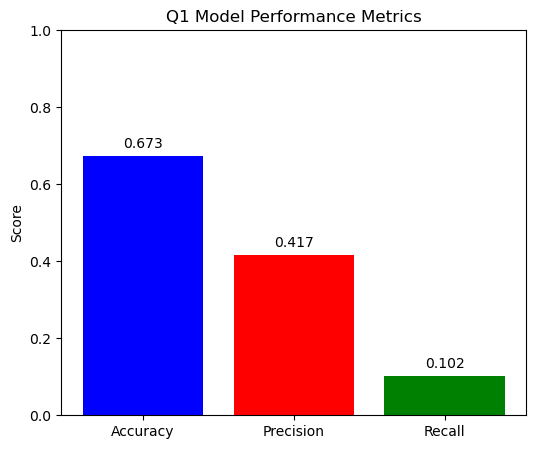

In [32]:
metrics = {
    "Accuracy": 0.673336509448944,
    "Precision": 0.41735537190082644,
    "Recall": 0.10217501264542236
}

plt.figure(figsize=(6,5))
plt.bar(metrics.keys(), metrics.values(), color=["blue","red","green"])
plt.title("Q1 Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)


for key, value in metrics.items():
    plt.text(key, value + 0.02, f"{value:.3f}", ha="center")
plt.show()


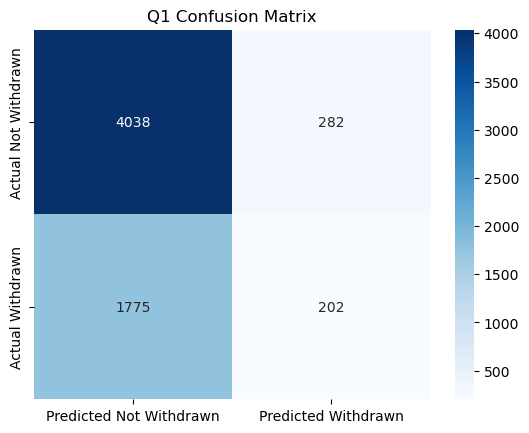

In [33]:

cm = np.array([[4038, 282],
               [1775, 202]])
plt.figure
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Not Withdrawn", "Predicted Withdrawn"],
            yticklabels=["Actual Not Withdrawn", "Actual Withdrawn"])
plt.title("Q1 Confusion Matrix")
plt.show()


In [12]:
# Here I will see the results of spliting data 70/30 
# Q1) Can demographic factors predict whether a student is likely to withdraw?
#create binary class label
df["Withdraw_Class"] = df["final_result"].map({
    "Withdrawn": 1,
    "Pass": 0,
    "Fail": 0,
    "Distinction": 0
})

#map categorical values to numbers
gender_map = {"M": 0, "F": 1}
df["gender_num"] = df["gender"].map(gender_map)

dis_map = {"N": 0, "Y": 1}
df["disability_num"] = df["disability"].map(dis_map)

age_map = {"0-35": 0, "35-55": 1, "55+": 2}
df["age_num"] = df["age_band"].map(age_map)


region_map = {
    "East Anglian Region": 0, "Scotland": 1, "North Western Region": 2, "South East Region": 3,
    "West Midlands Region": 4, "Wales": 5, "North Region": 6, "South Region": 7,
    "Ireland": 8, "South West Region": 9, "East Midlands Region": 10,"Yorkshire Region": 11, "London Region": 12
}
df["region_num"] = df["region"].map(region_map)
imd_map = {
    "0-10%": 0, "10-20%": 1, "20-30%": 2, "30-40%": 3,
    "40-50%": 4, "50-60%": 5, "60-70%": 6, "70-80%": 7,
    "80-90%": 8, "90-100%": 9
}
df["imd_num"] = df["imd_band"].map(imd_map)

edu_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}
df["edu_num"] = df["highest_education"].map(edu_map)

#features
features = ["gender_num", "age_num", "imd_num", "disability_num","region_num","edu_num"]
X = df[features]
y = df["Withdraw_Class"]

#train/test split (70-30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

#train decision tree
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)
#accuracy
print("Training Accuracy:", dtree.score(X_train, y_train))

#predictions
y_pred = dtree.predict(X_test)


#evaluation

print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Training Accuracy: 0.7036801742523937
Testing Accuracy: 0.6682901005823186
Precision: 0.3795534665099882
Recall: 0.11031420765027322
Confusion Matrix:
 [[5989  528]
 [2605  323]]


In [31]:
#  Here I will see the results of spliting data 60/40
# Q1) Can demographic factors predict whether a student is likely to withdraw?
#create binary class label
df["Withdraw_Class"] = df["final_result"].map({
    "Withdrawn": 1,
    "Pass": 0,
    "Fail": 0,
    "Distinction": 0
})

#map categorical values to numbers
gender_map = {"M": 0, "F": 1}
df["gender_num"] = df["gender"].map(gender_map)

dis_map = {"N": 0, "Y": 1}
df["disability_num"] = df["disability"].map(dis_map)

age_map = {"0-35": 0, "35-55": 1, "55+": 2}
df["age_num"] = df["age_band"].map(age_map)


region_map = {
    "East Anglian Region": 0, "Scotland": 1, "North Western Region": 2, "South East Region": 3,
    "West Midlands Region": 4, "Wales": 5, "North Region": 6, "South Region": 7,
    "Ireland": 8, "South West Region": 9, "East Midlands Region": 10,"Yorkshire Region": 11, "London Region": 12
}
df["region_num"] = df["region"].map(region_map)
imd_map = {
    "0-10%": 0, "10-20%": 1, "20-30%": 2, "30-40%": 3,
    "40-50%": 4, "50-60%": 5, "60-70%": 6, "70-80%": 7,
    "80-90%": 8, "90-100%": 9
}
df["imd_num"] = df["imd_band"].map(imd_map)

edu_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}
df["edu_num"] = df["highest_education"].map(edu_map)

#features
features = ["gender_num", "age_num", "imd_num", "disability_num","region_num","edu_num"]
X = df[features]
y = df["Withdraw_Class"]

#train/test split (60-40)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

#train decision tree
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)
#accuracy
print("Training Accuracy:", dtree.score(X_train, y_train))

#predictions
y_pred = dtree.predict(X_test)


#evaluation

print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Training Accuracy: 0.7058076128963947
Testing Accuracy: 0.668784245215596
Precision: 0.3883129123468426
Recall: 0.10472801220132182
Confusion Matrix:
 [[8010  649]
 [3522  412]]


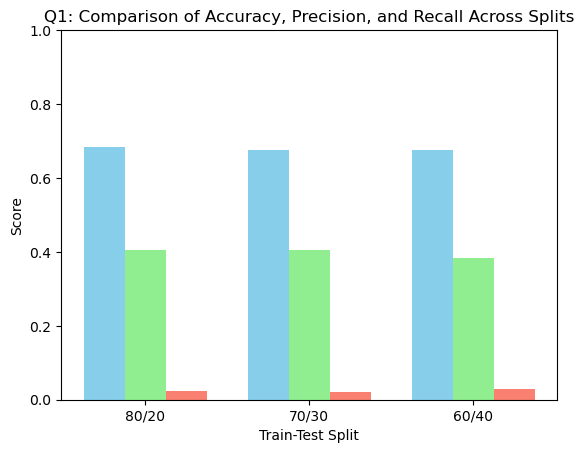

In [ ]:
splits = ["80/20", "70/30", "60/40"]

accuracy =  [0.6841, 0.6756, 0.6761]   
precision = [0.4050, 0.4052, 0.3841]  
recall =    [0.0249, 0.0204, 0.0302]   

#X positions
x = np.arange(len(splits))
width = 0.25  # width of each bar

plt.figure

#bars
plt.bar(x - width, accuracy,  width, label="Accuracy",  color="skyblue")
plt.bar(x,         precision, width, label="Precision", color="lightgreen")
plt.bar(x + width, recall,    width, label="Recall",    color="salmon")

#labels and title
plt.xlabel("Train-Test Split")
plt.ylabel("Score")
plt.title("Q1: Comparison of Accuracy, Precision, and Recall Across Splits")
plt.xticks(x, splits)
plt.ylim(0, 1)  


plt.show()


In [ ]:
# Q2) Can IMD background predict Pass(Pass/Distinction) vs Fail(Fail/Withdrawn)?

#create binary class label
df["PassFail_Class"] = df["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0
})

#map categorical values to numbers 

imd_map = {
    "0-10%": 0, "10-20%": 1, "20-30%": 2, "30-40%": 3,
    "40-50%": 4, "50-60%": 5, "60-70%": 6, "70-80%": 7,
    "80-90%": 8, "90-100%": 9
}
df["imd_num"] = df["imd_band"].map(imd_map)

#features 
features2 = ["imd_num"]
X2 = df[features2]
y2 = df["PassFail_Class"]

#train/test split (80/20)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2)

#train decision tree
dtree2 = DecisionTreeClassifier()
dtree2 = dtree2.fit(X2_train, y2_train)

#predictions
y2_pred = dtree2.predict(X2_test)

#evaluation
print("Training Accuracy:", dtree2.score(X2_train, y2_train))
print("Testing Accuracy:", accuracy_score(y2_test, y2_pred))
print("Precision:", precision_score(y2_test, y2_pred))
print("Recall:", recall_score(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))


Training Accuracy: 0.560015882469724
Testing Accuracy: 0.5601079879307607
Precision: 0.5273224043715847
Recall: 0.4006920415224913
Confusion Matrix:
 [[2369 1038]
 [1732 1158]]


In [ ]:
# Q2) Can IMD background predict Pass(Pass/Distinction) vs Fail(Fail/Withdrawn)?

#create binary class label
df["PassFail_Class"] = df["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0
})

#map categorical values to numbers 

imd_map = {
    "0-10%": 0, "10-20%": 1, "20-30%": 2, "30-40%": 3,
    "40-50%": 4, "50-60%": 5, "60-70%": 6, "70-80%": 7,
    "80-90%": 8, "90-100%": 9
}
df["imd_num"] = df["imd_band"].map(imd_map)

#features 
features2 = ["imd_num"]
X2 = df[features2]
y2 = df["PassFail_Class"]

#train/test split (70/30)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3)

#train decision tree
dtree2 = DecisionTreeClassifier()
dtree2 = dtree2.fit(X2_train, y2_train)

#predictions
y2_pred = dtree2.predict(X2_test)

#evaluation
print("Training Accuracy:", dtree2.score(X2_train, y2_train))
print("Testing Accuracy:", accuracy_score(y2_test, y2_pred))
print("Precision:", precision_score(y2_test, y2_pred))
print("Recall:", recall_score(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))


Training Accuracy: 0.5599219494486546
Testing Accuracy: 0.5602964531498147
Precision: 0.5495954450104885
Recall: 0.4090098126672614
Confusion Matrix:
 [[3458 1503]
 [2650 1834]]


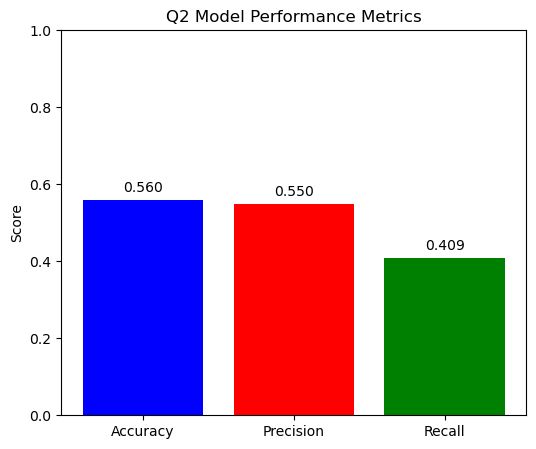

In [54]:
#the best split result 70/30
metrics = {
    "Accuracy": 0.5602964531498147,
    "Precision": 0.5495954450104885,
    "Recall": 0.4090098126672614
}

plt.figure(figsize=(6,5))
plt.bar(metrics.keys(), metrics.values(), color=["blue","red","green"])
plt.title("Q2 Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)


for key, value in metrics.items():
    plt.text(key, value + 0.02, f"{value:.3f}", ha="center")
plt.show()

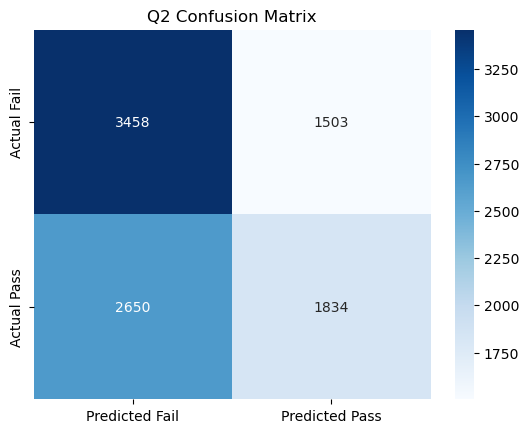

In [39]:
cm = np.array([[3458, 1503],
               [2650, 1834]]) 

plt.figure
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Fail", "Predicted Pass"], 
            yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Q2 Confusion Matrix")
plt.show()

In [ ]:
# Q2) Can IMD background predict Pass(Pass/Distinction) vs Fail(Fail/Withdrawn)?

#create binary class label
df["PassFail_Class"] = df["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0
})

#map categorical values to numbers 

imd_map = {
    "0-10%": 0, "10-20%": 1, "20-30%": 2, "30-40%": 3,
    "40-50%": 4, "50-60%": 5, "60-70%": 6, "70-80%": 7,
    "80-90%": 8, "90-100%": 9
}
df["imd_num"] = df["imd_band"].map(imd_map)

#features 
features2 = ["imd_num"]
X2 = df[features2]
y2 = df["PassFail_Class"]

#train/test split (60/40)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.4)

#train decision tree
dtree2 = DecisionTreeClassifier()
dtree2 = dtree2.fit(X2_train, y2_train)

#predictions
y2_pred = dtree2.predict(X2_test)

#evaluation
print("Training Accuracy:", dtree2.score(X2_train, y2_train))
print("Testing Accuracy:", accuracy_score(y2_test, y2_pred))
print("Precision:", precision_score(y2_test, y2_pred))
print("Recall:", recall_score(y2_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))


Training Accuracy: 0.5594261210228175
Testing Accuracy: 0.5609465576113714
Precision: 0.5292782569223786
Recall: 0.40297217902194576
Confusion Matrix:
 [[4732 2074]
 [3455 2332]]


<function matplotlib.pyplot.show(close=None, block=None)>

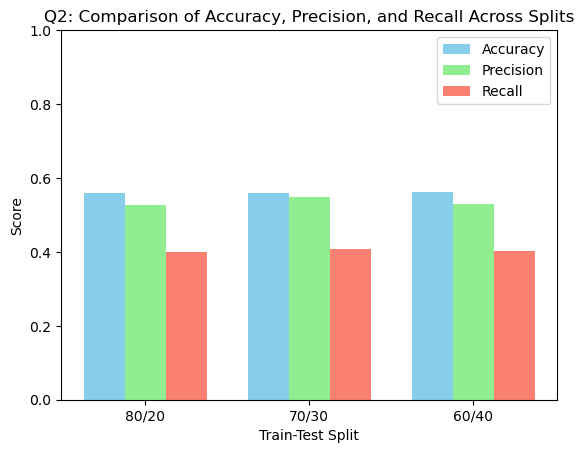

In [ ]:
# Q2 results for each split
splits = ["80/20", "70/30", "60/40"]

accuracy =  [0.5601, 0.5602, 0.5609]
precision = [0.5273, 0.5495, 0.5292]
recall =    [0.4007, 0.4090, 0.4029]

x = np.arange(len(splits))
width = 0.25

plt.figure

#create bars
plt.bar(x - width, accuracy,  width, label="Accuracy",  color="skyblue")
plt.bar(x,         precision, width, label="Precision", color="lightgreen")
plt.bar(x + width, recall,    width, label="Recall",    color="salmon")


plt.xlabel("Train-Test Split")
plt.ylabel("Score")
plt.title("Q2: Comparison of Accuracy, Precision, and Recall Across Splits")
plt.xticks(x, splits)
plt.ylim(0, 1)
plt.legend()
plt.show

In [ ]:
# Q3) Can educational background classify students likely to achieve a distinction?

#create binary class label
df["Distinction_Class"] = df["final_result"].map({
    "Distinction": 1,
    "Pass": 0,
    "Fail": 0,
    "Withdrawn": 0
})

#map categorical values to numbers 

edu_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}
df["edu_num"] = df["highest_education"].map(edu_map)


#features 
features3 = ["edu_num"]
X3 = df[features3]
y3 = df["Distinction_Class"]

#train/test split (80/20)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2)

#train decision tree
dtree3 = DecisionTreeClassifier()
dtree3 = dtree3.fit(X3_train, y3_train)

#predictions
y3_pred = dtree3.predict(X3_test)

#evaluation
print("Training Accuracy:", dtree3.score(X3_train, y3_train))
print("Testing Accuracy:", accuracy_score(y3_test, y3_pred))
print("Precision:", precision_score(y3_test, y3_pred))
print("Recall:", recall_score(y3_test, y3_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_test, y3_pred))


Training Accuracy: 0.9096684534445106
Testing Accuracy: 0.9126568207082738
Precision: 0.0
Recall: 0.0
Confusion Matrix:
 [[5747    0]
 [ 550    0]]


f:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Q3) Can educational background classify students likely to achieve a distinction?

#create binary class label
df["Distinction_Class"] = df["final_result"].map({
    "Distinction": 1,
    "Pass": 0,
    "Fail": 0,
    "Withdrawn": 0
})

#map categorical values to numbers 

edu_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}
df["edu_num"] = df["highest_education"].map(edu_map)


#features 
features3 = ["edu_num"]
X3 = df[features3]
y3 = df["Distinction_Class"]

#train/test split (70/30)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.3)

#train decision tree
dtree3 = DecisionTreeClassifier()
dtree3 = dtree3.fit(X3_train, y3_train)

#predictions
y3_pred = dtree3.predict(X3_test)

#evaluation
print("Training Accuracy:", dtree3.score(X3_train, y3_train))
print("Testing Accuracy:", accuracy_score(y3_test, y3_pred))
print("Precision:", precision_score(y3_test, y3_pred))
print("Recall:", recall_score(y3_test, y3_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_test, y3_pred))


Training Accuracy: 0.9088351408993964
Testing Accuracy: 0.9136050820539968
Precision: 0.0
Recall: 0.0
Confusion Matrix:
 [[8629    0]
 [ 816    0]]


f:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


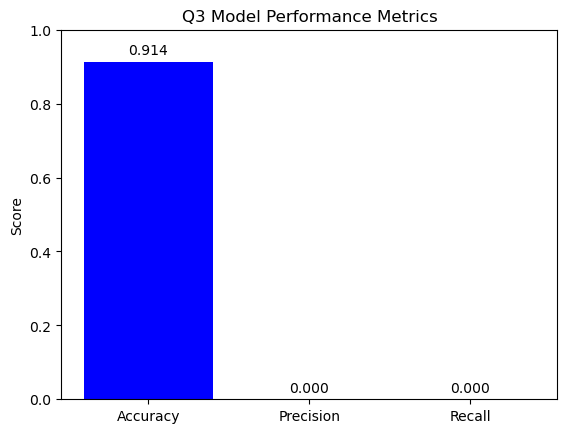

In [51]:
#the best split result 70/30
metrics = {
    "Accuracy": 0.9136050820539968,
    "Precision": 0.0 ,
    "Recall": 0.0
}

plt.figure
plt.bar(metrics.keys(), metrics.values(), color=["blue","red","green"])
plt.title("Q3 Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)


for key, value in metrics.items():
    plt.text(key, value + 0.02, f"{value:.3f}", ha="center")
plt.show()

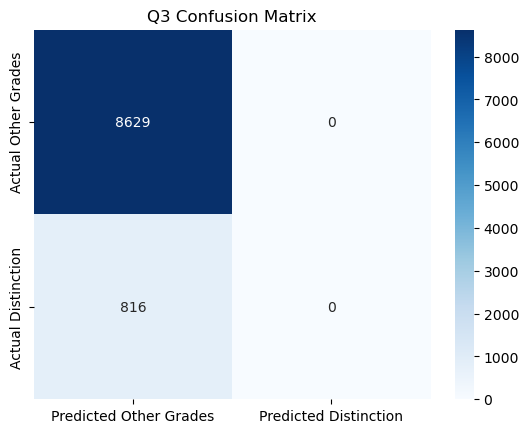

In [50]:
cm = np.array([[8629, 0],
               [816, 0]]) 

plt.figure
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Other Grades", "Predicted Distinction"], 
            yticklabels=["Actual Other Grades", "Actual Distinction"])
plt.title("Q3 Confusion Matrix")
plt.show()

In [ ]:
# Q3) Can educational background classify students likely to achieve a distinction?

#create binary class label
df["Distinction_Class"] = df["final_result"].map({
    "Distinction": 1,
    "Pass": 0,
    "Fail": 0,
    "Withdrawn": 0
})

#map categorical values to numbers 

edu_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}
df["edu_num"] = df["highest_education"].map(edu_map)


#features 
features3 = ["edu_num"]
X3 = df[features3]
y3 = df["Distinction_Class"]

#train/test split (60/40)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.4)

#train decision tree
dtree3 = DecisionTreeClassifier()
dtree3 = dtree3.fit(X3_train, y3_train)

#predictions
y3_pred = dtree3.predict(X3_test)

#evaluation
print("Training Accuracy:", dtree3.score(X3_train, y3_train))
print("Testing Accuracy:", accuracy_score(y3_test, y3_pred))
print("Precision:", precision_score(y3_test, y3_pred))
print("Recall:", recall_score(y3_test, y3_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_test, y3_pred))


Training Accuracy: 0.9115358144952088
Testing Accuracy: 0.9083617882950845
Precision: 0.0
Recall: 0.0
Confusion Matrix:
 [[11439     0]
 [ 1154     0]]


f:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


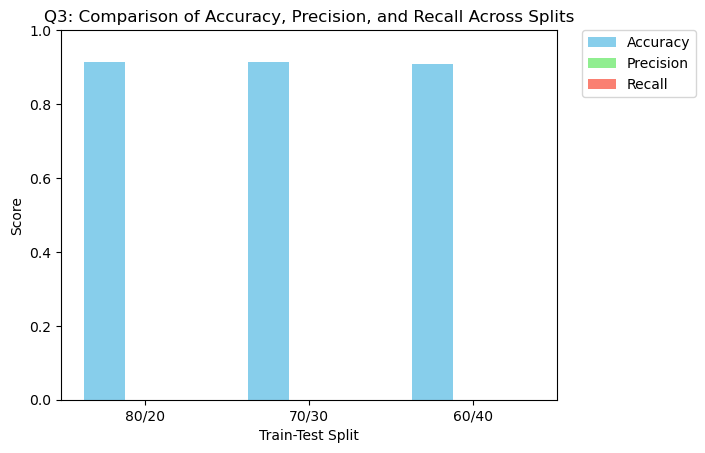

In [ ]:
# Q3 results for each split
splits = ["80/20", "70/30", "60/40"]

accuracy =  [0.9127, 0.9136, 0.9084]
precision = [0.0,    0.0,    0.0   ]
recall =    [0.0,    0.0,    0.0   ]

x = np.arange(len(splits))
width = 0.25

plt.figure

#create bars
bars_acc = plt.bar(x - width, accuracy,  width, label="Accuracy",  color="skyblue")
bars_pre = plt.bar(x,         precision, width, label="Precision", color="lightgreen")
bars_rec = plt.bar(x + width, recall,    width, label="Recall",    color="salmon")



plt.xlabel("Train-Test Split")
plt.ylabel("Score")
plt.title("Q3: Comparison of Accuracy, Precision, and Recall Across Splits")
plt.xticks(x, splits)
plt.ylim(0, 1)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)
plt.show()
